# Exporting an ImageCollection to NetCDF

## Introduction

[XEE](https://github.com/google/Xee) is a XArray extension that allows reading data from Google Earth Engine (GEE). This extension is useful for extracting subsets of data hosted in GEE. In this tutorial, we will learn how to extract a large ImageCollection and save it as a local NetCDF file.

## Overview of the Task

We will take the [ERA5-Land Daily Aggregated](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR) collection and export the subset for the chosen country as a CF-compatible format NetCDF file.

**Input Layers**:
* `ne_10m_admin_0_countries_ind.zip`: A shapefile of country boundaries

**Output**:
* `era5_subset.nc`: A NetCDF subset of the ERA5-Land Daily Aggregated data.

**Data Credit**:
- ERA5-Land monthly averaged data from 1981 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS).
- Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.

**Running the Notebook**:
The preferred way to run this notebook is on Google Colab.
<a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/xee_ic_to_netcdf.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install xee rioxarray netCDF4 dask['distributed']

In [2]:
import ee
import geopandas as gpd
import numpy as np
import os
import rioxarray as rxr
import xarray as xr
from xee import helpers

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [4]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

shapefile = 'ne_10m_admin_0_countries_ind.zip'

data_url = 'https://github.com/spatialthoughts/geopython-tutorials/releases/download/data/'
download('{}/{}'.format(data_url,shapefile))

Downloaded data/ne_10m_admin_0_countries_ind.zip


## Initialize EE and Dask Cluster

Initialize EE with the [High-Volume EndPoint](https://developers.google.com/earth-engine/guides/processing_environments#high-volume_endpoint) which is recommended to be used with XEE for workflows that do not use a lot of server side processing and are primarily for extracting data from stored collections. Replace the value of the `cloud_project` variable with your own project id that is linked with GEE.


In [13]:
cloud_project = 'spatialthoughts' # replace with your project id

try:
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')
except:
    ee.Authenticate()
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')

Setup a local Dask cluster.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


Each of our Dask workers need Earth Engine authentication. Initialize Dask workers using `ee.Initialize()`.

In [ ]:
from dask.distributed import WorkerPlugin

class EEPlugin(WorkerPlugin):
    def __init__(self):
        pass
    def setup(self, worker):
        self.worker = worker
        try:
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')
        except:
            ee.Authenticate()
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')

ee_plugin = EEPlugin()
client.register_plugin(ee_plugin)


## Data Preparation

We read the Natural Earth administrative regions shapefile and select a country.

In [16]:
shapefile_path = os.path.join(data_folder, shapefile)
boundaries_gdf = gpd.read_file(shapefile_path)

Select the country of your choice using the [3-letter ISO code](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3) for your country. Here we use `GHA` for Ghana.

In [17]:
country = boundaries_gdf[boundaries_gdf['ADM0_A3'] == 'GHA']
geometry = country.geometry.union_all()

Configure the time period and variables.

In [11]:
start_year = 2023
end_year = 2024
variable = 'temperature_2m'

Define the ImageCollection and apply filters using the Earth Engine Python API syntax.

In [18]:
start_date = ee.Date.fromYMD(start_year, 1, 1)
end_date = ee.Date.fromYMD(end_year + 1, 1, 1)
bbox = ee.Algorithms.GeometryConstructors.BBox(*geometry.bounds)

era5 = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
filtered = era5 \
  .filter(ee.Filter.date(start_date, end_date)) \
  .filter(ee.Filter.bounds(bbox)) \
  .select(variable)

We now read the filtered collecting using XEE. XEE requires explicit grid parameters. We extract these using the helper function [`extract_grid_params`](hhttps://xee.readthedocs.io/en/latest/_autosummary/xee.extract_grid_params.html#xee.extract_grid_params).

In [15]:
grid_params = helpers.extract_grid_params(filtered)
grid_params

{'crs': 'EPSG:4326',
 'crs_transform': (0.1, 0, -180.05, 0, -0.1, 90.05),
 'shape_2d': (3601, 1801)}

In [16]:
ds = xr.open_dataset(
    filtered,
    engine='ee',
    **grid_params,
    chunks={}
)
ds

<xarray.Dataset> Size: 19GB
Dimensions:         (time: 731, y: 1801, x: 3601)
Coordinates:
  * time            (time) datetime64[ns] 6kB 2023-01-01 ... 2024-12-31
  * y               (y) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * x               (x) float64 29kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Data variables:
    temperature_2m  (time, y, x) float32 19GB dask.array<chunksize=(48, 256, 256), meta=np.ndarray>

Clip the pixels outside the geometry.

In [22]:
clipped_ds = ds \
  .rio.clip(country.geometry.values)
clipped_ds

<xarray.Dataset> Size: 8MB
Dimensions:         (time: 731, y: 64, x: 44)
Coordinates:
  * time            (time) datetime64[ns] 6kB 2023-01-01 ... 2024-12-31
  * y               (y) float64 512B 11.1 11.0 10.9 10.8 ... 5.1 5.0 4.9 4.8
  * x               (x) float64 352B -3.2 -3.1 -3.0 -2.9 ... 0.8 0.9 1.0 1.1
    spatial_ref     int64 8B 0
Data variables:
    temperature_2m  (time, y, x) float32 8MB dask.array<chunksize=(48, 64, 24), meta=np.ndarray>

Now we can call `compute()` to load this into memory. This will trigger parallel pixel fetches to get the required pixels. As we had setup a Dask LocalCluster, the process will be paralellized across all available cores of the machine. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [19]:
%%time
clipped_ds = clipped_ds.compute()

CPU times: user 9.57 s, sys: 954 ms, total: 10.5 s
Wall time: 1min 26s


## Visualize and Export

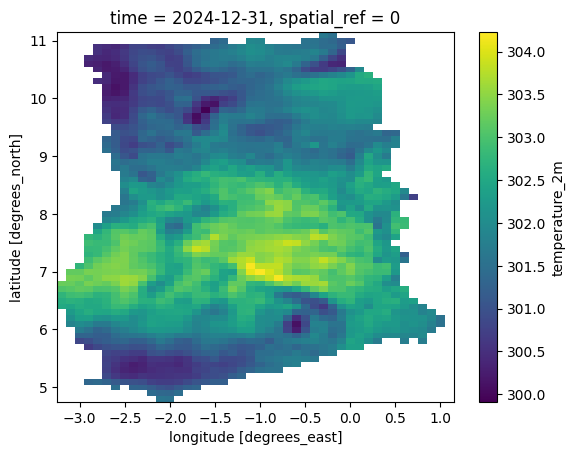

In [24]:
# Plot a single timestep to verify the data
clipped_ds[variable].isel(time=-1).plot.imshow()

Save the results as a NetCDF file.

In [21]:
%%time
output_file = f'era5_subset.nc'
output_path = os.path.join(output_folder, output_file)

# Enable compression
encoding = {variable: {'zlib': True}}
clipped_ds.to_netcdf(output_path, encoding=encoding)

CPU times: user 415 ms, sys: 37.3 ms, total: 452 ms
Wall time: 423 ms


----

If you want to give feedback or share your experience with this tutorial, please comment below. (requires GitHub account)


<script src='https://utteranc.es/client.js'
    repo='spatialthoughts/geopython-tutorials'
    issue-term='pathname'
    theme='github-light'
    crossorigin='anonymous'
    async>
</script>